# Chapter 9: Autonomous Bioinformatics Workflow Orchestration

## Hands-On Jupyter Notebook

This notebook builds an offline orchestrator for RNA-seq style pipelines using synthetic sample metadata, quality gates, and scheduling logic.

**Time to Complete**: 1-2 hours

**What You Will Build**
- A synthetic set of sequencing jobs
- A workflow orchestration plan with QC and analysis stages
- A simple compute-lane scheduler
- Validation exercises for quality gating and prioritization

---

## Section 1: Setup and Imports

We configure the notebook for deterministic orchestration simulations and compact reporting.

In [1]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print('Environment configured for Chapter 9 orchestration notebook.')

Environment configured for Chapter 9 orchestration notebook.


## Section 2: Synthetic Workflow Queue

We create a queue of sequencing jobs with quality signals that influence orchestration decisions.

In [2]:
jobs_df = pd.DataFrame(
    [
        {'workflow_id': 'bio_01', 'assay': 'RNA-seq', 'read_depth_million': 42, 'contamination_pct': 1.2, 'batch': 'A', 'urgency': 'high'},
        {'workflow_id': 'bio_02', 'assay': 'RNA-seq', 'read_depth_million': 28, 'contamination_pct': 3.8, 'batch': 'A', 'urgency': 'medium'},
        {'workflow_id': 'bio_03', 'assay': 'WGS', 'read_depth_million': 90, 'contamination_pct': 0.7, 'batch': 'B', 'urgency': 'high'},
        {'workflow_id': 'bio_04', 'assay': 'WES', 'read_depth_million': 65, 'contamination_pct': 2.4, 'batch': 'B', 'urgency': 'medium'},
        {'workflow_id': 'bio_05', 'assay': 'RNA-seq', 'read_depth_million': 18, 'contamination_pct': 5.1, 'batch': 'C', 'urgency': 'low'},
        {'workflow_id': 'bio_06', 'assay': 'Targeted-panel', 'read_depth_million': 12, 'contamination_pct': 1.0, 'batch': 'C', 'urgency': 'low'},
    ]
)

jobs_df['estimated_runtime_min'] = (jobs_df['read_depth_million'] * 1.1 + jobs_df['contamination_pct'] * 4).round(1)
jobs_df['qc_risk'] = np.where(jobs_df['contamination_pct'] >= 4.0, 'elevated', np.where(jobs_df['contamination_pct'] >= 2.0, 'moderate', 'low'))

display(jobs_df)

,workflow_id,assay,read_depth_million,contamination_pct,batch,urgency,estimated_runtime_min,qc_risk
0,bio_01,RNA-seq,42,1.2,A,high,51.0,low
1,bio_02,RNA-seq,28,3.8,A,medium,46.0,moderate
2,bio_03,WGS,90,0.7,B,high,101.8,low
3,bio_04,WES,65,2.4,B,medium,81.1,moderate
4,bio_05,RNA-seq,18,5.1,C,low,40.2,elevated
5,bio_06,Targeted-panel,12,1.0,C,low,17.2,low


## Section 3: Orchestration Logic

We route each workflow through QC, alignment, and downstream analysis stages while surfacing escalation flags.

In [3]:
def orchestrate_workflow(row: pd.Series) -> dict[str, object]:
    if row['contamination_pct'] >= 4.0:
        qc_status = 'manual_review'
        alignment_strategy = 'decontaminate_then_align'
    elif row['contamination_pct'] >= 2.0:
        qc_status = 'review_before_alignment'
        alignment_strategy = 'standard_align_with_qc_notes'
    else:
        qc_status = 'pass'
        alignment_strategy = 'standard_align'

    downstream = 'variant_calling' if row['assay'] in {'WGS', 'WES'} else 'expression_quantification'
    escalate = bool(row['urgency'] == 'high' and qc_status != 'pass')
    plan = {
        'workflow_id': row['workflow_id'],
        'qc_status': qc_status,
        'alignment_strategy': alignment_strategy,
        'downstream_stage': downstream,
        'escalate': escalate,
        'estimated_runtime_min': row['estimated_runtime_min'],
    }
    return plan

orchestration_df = pd.DataFrame([orchestrate_workflow(r) for _, r in jobs_df.iterrows()])
display(orchestration_df)

,workflow_id,qc_status,alignment_strategy,downstream_stage,escalate,estimated_runtime_min
0,bio_01,pass,standard_align,expression_quantification,False,51.0
1,bio_02,review_before_alignment,standard_align_with_qc_notes,expression_quantification,False,46.0
2,bio_03,pass,standard_align,variant_calling,False,101.8
3,bio_04,review_before_alignment,standard_align_with_qc_notes,variant_calling,False,81.1
4,bio_05,manual_review,decontaminate_then_align,expression_quantification,False,40.2
5,bio_06,pass,standard_align,expression_quantification,False,17.2


## Section 4: Visualization

Create visualizations to present findings.

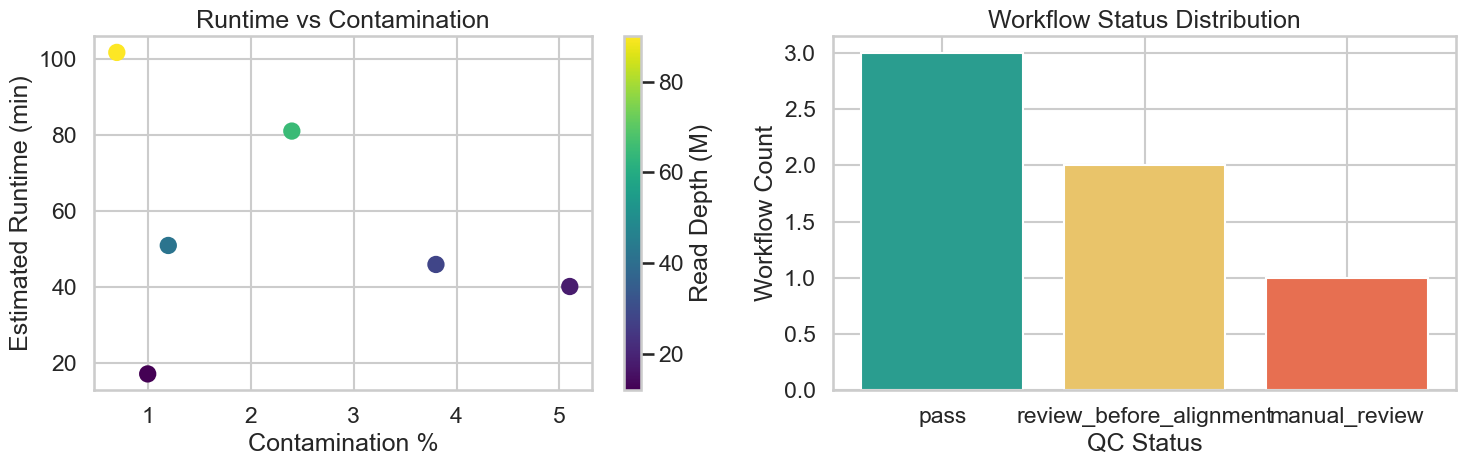

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(jobs_df['contamination_pct'], jobs_df['estimated_runtime_min'], c=jobs_df['read_depth_million'], cmap='viridis', s=120)
axes[0].set_xlabel('Contamination %')
axes[0].set_ylabel('Estimated Runtime (min)')
axes[0].set_title('Runtime vs Contamination')
scatter = axes[0].collections[0]
fig.colorbar(scatter, ax=axes[0], label='Read Depth (M)')

status_counts = orchestration_df['qc_status'].value_counts()
axes[1].bar(status_counts.index, status_counts.values, color=['#2A9D8F', '#E9C46A', '#E76F51'])
axes[1].set_xlabel('QC Status')
axes[1].set_ylabel('Workflow Count')
axes[1].set_title('Workflow Status Distribution')

plt.tight_layout()
plt.show()

## Section 4: Visualization

We inspect how QC risk relates to runtime and how workflows distribute across orchestration states.

In [ ]:
## Section 5: Exercises

### Exercise 1: QC Gate

Implement a QC gate that classifies workflows into pass, review, or manual review based on contamination and read depth.

### Exercise 2: Scheduler Priority

Build a scheduler that ranks jobs by urgency, contamination risk, and estimated runtime.

In [5]:
def qc_gate(row: pd.Series) -> str:
    if row['contamination_pct'] >= 4.0:
        return 'manual_review'
    if row['contamination_pct'] >= 2.0 or row['read_depth_million'] < 20:
        return 'review'
    return 'pass'

qc_results = jobs_df[['workflow_id', 'contamination_pct', 'read_depth_million']].copy()
qc_results['qc_gate'] = qc_results.apply(qc_gate, axis=1)

display(qc_results)

,workflow_id,contamination_pct,read_depth_million,qc_gate
0,bio_01,1.2,42,pass
1,bio_02,3.8,28,review
2,bio_03,0.7,90,pass
3,bio_04,2.4,65,review
4,bio_05,5.1,18,manual_review
5,bio_06,1.0,12,review


## Section 6: Key Takeaways

- Orchestrators should make QC state explicit before downstream execution.
- Runtime estimation helps balance compute demand across batches.
- Escalation rules prevent high-risk workflows from silently proceeding.
- Simple scheduling policies can reveal bottlenecks before scaling up.
- Structured workflow plans are easier to audit than narrative-only logs.


## Next Steps

1. Add failure retries and checkpoint persistence.
2. Extend the scheduler with compute-node capacity constraints.
3. Link Chapter 9 job plans to Chapter 10 single-cell processing examples.
4. Add provenance fields for tool versions and reference genomes.


**Last Updated**: May 2026